In [1]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
# BoM MJO RMM index text file
file_path = "rmm.74toRealtime.txt"

rows = []
with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line = line.strip()
        # skip headers / blank lines (they don't start with a digit)
        if not line or not line[0].isdigit():
            continue
        parts = line.split()
        # need at least 7 tokens: year month day RMM1 RMM2 phase amplitude
        if len(parts) < 7:
            continue
        try:
            y = int(parts[0]); m = int(parts[1]); d = int(parts[2])
            rmm1 = float(parts[3])
            rmm2 = float(parts[4])
            phase = int(float(parts[5]))        # sometimes written as float-like text
            amp   = float(parts[6])

            # treat BoM missing codes as NaN/skip
            if amp == 999 or abs(amp) >= 1e35 or abs(rmm1) >= 1e35 or abs(rmm2) >= 1e35:
                continue

            rows.append([datetime(y, m, d), rmm1, rmm2, phase, amp])
        except Exception:
            # ignore any odd footer or malformed lines
            continue

df = pd.DataFrame(rows, columns=["date","RMM1","RMM2","phase","amplitude"]).sort_values("date").reset_index(drop=True)

print("✅ Parsed successfully")
print("Date range:", df["date"].min(), "→", df["date"].max())
print("Rows:", len(df))
print(df.tail())

✅ Parsed successfully
Date range: 1974-06-01 00:00:00 → 2024-02-24 00:00:00
Rows: 17876
            date      RMM1      RMM2  phase  amplitude
17871 2024-02-20 -0.305918  0.305419      8   0.432281
17872 2024-02-21  0.103033  0.071931      5   0.125658
17873 2024-02-22  0.236122  0.248544      6   0.342823
17874 2024-02-23  0.201856  0.325106      6   0.382675
17875 2024-02-24 -0.003146  0.128460      7   0.128498


In [3]:
# --- Filter for active MJO and winter months ---
active = df[df["amplitude"] > 1.0].copy()
active["month"] = active["date"].dt.month
active = active[active["month"].isin([11, 12, 1, 2, 3])]

# Optional: add a composite key for convenience
active["year_month"] = active["date"].dt.to_period("M")

print("Active winter days:", len(active))
print(active.head())

Active winter days: 4921
          date      RMM1      RMM2  phase  amplitude  month year_month
163 1974-11-11 -0.674690  0.781394      7    1.03237     11    1974-11
164 1974-11-12 -0.861200  0.737709      8    1.13396     11    1974-11
165 1974-11-13 -0.774430  0.753206      8    1.08030     11    1974-11
175 1974-11-23  0.862785  0.618138      5    1.06136     11    1974-11
177 1974-11-25  0.970875  0.384895      5    1.04439     11    1974-11


In [4]:
# Assuming df has ['date', 'RMM1', 'RMM2', 'phase', 'amplitude']
# and covers 1974–2024

# Convert to monthly
mjo_monthly = (
    df.resample("MS", on="date")
      .agg({"RMM1": "mean", "RMM2": "mean", "phase": lambda x: x.mode()[0] if len(x) > 0 else pd.NA,
            "amplitude": "mean"})
      .reset_index()
)

mjo_monthly["ym"] = mjo_monthly["date"].dt.to_period("M")
print(mjo_monthly.head())

        date      RMM1      RMM2 phase  amplitude       ym
0 1974-06-01  0.000494  0.178668     1   1.054615  1974-06
1 1974-07-01  0.388175 -0.022093     3   0.850042  1974-07
2 1974-08-01  0.404221  0.532801     5   1.074155  1974-08
3 1974-09-01 -0.633847 -0.612187     1   0.973811  1974-09
4 1974-10-01  0.836871  0.073818     5   0.992196  1974-10


In [5]:
# Load full Albany dataset
file = "ERA5Albanyhourly2mTemp.csv"
t = pd.read_csv(file)

# Parse timestamps and convert temperature from Kelvin → Celsius
t["valid_time"] = pd.to_datetime(t["valid_time"])
t["temp_C"] = t["t2m"] - 273.15

# Compute daily means
t_daily = t.set_index("valid_time").resample("D")["temp_C"].mean().reset_index()

# Display a quick check
print("Rows (hourly):", len(t), "→ Rows (daily):", len(t_daily))
print("Range:", t_daily["valid_time"].min(), "-", t_daily["valid_time"].max())
print(t_daily.head())

Rows (hourly): 454368 → Rows (daily): 18932
Range: 1974-01-01 00:00:00 - 2025-10-31 00:00:00
  valid_time    temp_C
0 1974-01-01 -0.895343
1 1974-01-02 -5.384398
2 1974-01-03 -4.778581
3 1974-01-04 -4.604736
4 1974-01-05 -6.747163


In [6]:
# Ensure both datasets are ready
rmm = df.copy()  # RMM dataset from earlier
rmm["date"] = pd.to_datetime(rmm["date"])
t_daily["date"] = pd.to_datetime(t_daily["valid_time"])

# Merge on date
merged = pd.merge(t_daily, rmm, on="date", how="inner")

print("Merged rows:", len(merged))
print(merged.head())

Merged rows: 17876
  valid_time     temp_C       date     RMM1     RMM2  phase  amplitude
0 1974-06-01  18.451497 1974-06-01  1.63447  1.20304      5    2.02948
1 1974-06-02  16.793263 1974-06-02  1.60289  1.01512      5    1.89729
2 1974-06-03  16.448903 1974-06-03  1.51625  1.08551      5    1.86476
3 1974-06-04  16.616939 1974-06-04  1.50981  1.03573      5    1.83092
4 1974-06-05  21.435043 1974-06-05  1.55906  1.30518      5    2.03326


In [7]:
t_daily["month"] = t_daily["valid_time"].dt.month
t_winter = t_daily[t_daily["month"].isin([11, 12, 1, 2, 3])].copy()
print("Rows (Nov–Mar only):", len(t_winter))

Rows (Nov–Mar only): 7804


In [8]:
# Calculate the day-of-year (DOY)
t_winter["doy"] = t_winter["valid_time"].dt.dayofyear

# Build full climatology (1974–2024 mean temperature for each DOY)
clim = t_winter.groupby("doy")["temp_C"].mean()

# Subtract to get anomaly
t_winter["temp_anom"] = t_winter.apply(lambda x: x["temp_C"] - clim.loc[x["doy"]], axis=1)

In [9]:
rmm["date"] = pd.to_datetime(rmm["date"])
merged = pd.merge(t_winter, rmm, left_on="valid_time", right_on="date", how="inner")

print("Merged winter rows:", len(merged))

Merged winter rows: 7451


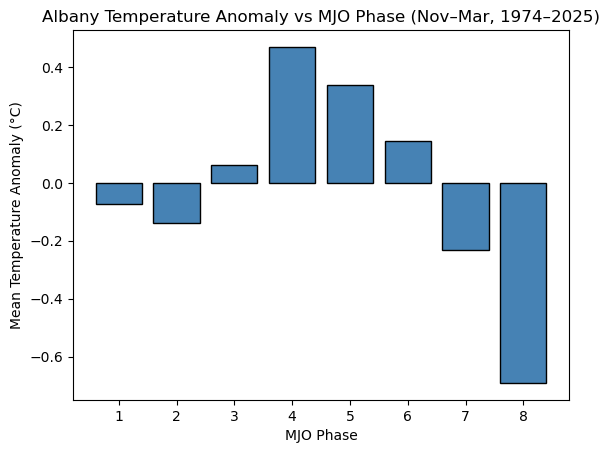

In [10]:
phase_mean = merged.groupby("phase")["temp_anom"].mean()

plt.bar(phase_mean.index, phase_mean.values, color="steelblue", edgecolor="k")
plt.xlabel("MJO Phase")
plt.ylabel("Mean Temperature Anomaly (°C)")
plt.title("Albany Temperature Anomaly vs MJO Phase (Nov–Mar, 1974–2025)")
plt.show()

In [11]:
merged["date"] = pd.to_datetime(merged["valid_time"])
merged = merged.sort_values("date").reset_index(drop=True)

In [12]:
max_lag = 20
lags = range(0, max_lag + 1)

results = []

for lag in lags:
    # shift RMMs backward (so today's temperature corresponds to MJO 'lag' days ago)
    merged["RMM1_lag"] = merged["RMM1"].shift(lag)
    merged["RMM2_lag"] = merged["RMM2"].shift(lag)

    # drop missing values caused by shifting
    subset = merged.dropna(subset=["RMM1_lag", "RMM2_lag", "temp_anom"])

    # simple linear regression (RMM1, RMM2 → temp_anom)
    from sklearn.linear_model import LinearRegression
    X = subset[["RMM1_lag", "RMM2_lag"]]
    y = subset["temp_anom"]

    model = LinearRegression().fit(X, y)
    r = np.corrcoef(y, model.predict(X))[0, 1]

    results.append({
        "lag_days": lag,
        "beta_RMM1": model.coef_[0],
        "beta_RMM2": model.coef_[1],
        "r": r
    })

lag_df = pd.DataFrame(results)
print(lag_df.head())

   lag_days  beta_RMM1  beta_RMM2         r
0         0   0.320230   0.058086  0.064773
1         1   0.362380   0.018464  0.072920
2         2   0.407226  -0.015002  0.082592
3         3   0.431498  -0.053795  0.088981
4         4   0.431813  -0.092713  0.091329


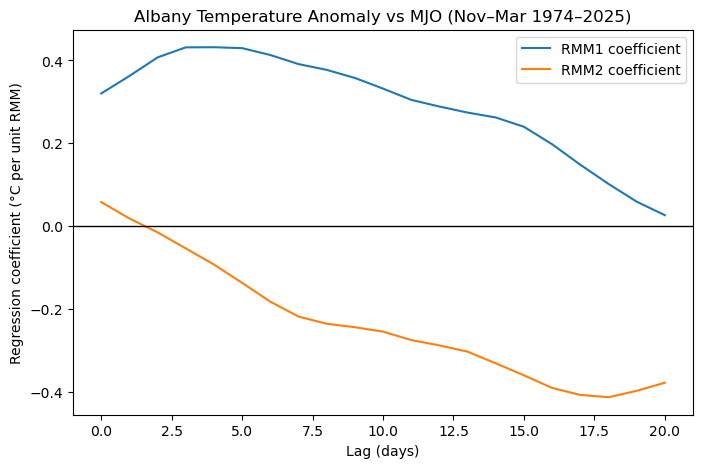

In [13]:
plt.figure(figsize=(8,5))
plt.plot(lag_df["lag_days"], lag_df["beta_RMM1"], label="RMM1 coefficient")
plt.plot(lag_df["lag_days"], lag_df["beta_RMM2"], label="RMM2 coefficient")
plt.axhline(0, color="k", lw=1)
plt.xlabel("Lag (days)")
plt.ylabel("Regression coefficient (°C per unit RMM)")
plt.title("Albany Temperature Anomaly vs MJO (Nov–Mar 1974–2025)")
plt.legend()
plt.show()

In [14]:
def block_bootstrap(series, block_size=30):
    """Return a bootstrap sample preserving autocorrelation."""
    n = len(series)
    idx = np.arange(n)
    bs_idx = []
    while len(bs_idx) < n:
        start = np.random.randint(0, n - block_size)
        bs_idx.extend(idx[start:start + block_size])
    return series.iloc[bs_idx[:n]].reset_index(drop=True)

In [15]:
boot_results = []
n_boot = 500

for lag in range(0, 21):
    merged["RMM1_lag"] = merged["RMM1"].shift(lag)
    merged["RMM2_lag"] = merged["RMM2"].shift(lag)

    d = merged.dropna(subset=["temp_anom", "RMM1_lag", "RMM2_lag"])

    X_real = sm.add_constant(d[["RMM1_lag", "RMM2_lag"]]).reset_index(drop=True)
    y_real = d["temp_anom"].reset_index(drop=True)

    # real slope
    real_model = sm.OLS(y_real, X_real).fit()
    real_beta = real_model.params["RMM1_lag"]

    boot_betas = []
    for _ in range(n_boot):
        y_bs = block_bootstrap(y_real, block_size=30).reset_index(drop=True)
        bs_model = sm.OLS(y_bs, X_real).fit()
        boot_betas.append(bs_model.params["RMM1_lag"])

    p = np.mean(np.abs(boot_betas) >= np.abs(real_beta))

    boot_results.append({
        "lag": lag,
        "beta": real_beta,
        "p_bootstrap": p
    })

boot_df = pd.DataFrame(boot_results)
print(boot_df)

    lag      beta  p_bootstrap
0     0  0.320230        0.002
1     1  0.362380        0.000
2     2  0.407226        0.000
3     3  0.431498        0.002
4     4  0.431813        0.000
5     5  0.429586        0.000
6     6  0.413050        0.000
7     7  0.391139        0.000
8     8  0.377157        0.002
9     9  0.357655        0.000
10   10  0.331976        0.006
11   11  0.304779        0.006
12   12  0.288657        0.008
13   13  0.274076        0.022
14   14  0.262284        0.026
15   15  0.239739        0.038
16   16  0.197658        0.086
17   17  0.148210        0.232
18   18  0.101911        0.362
19   19  0.059099        0.596
20   20  0.026397        0.810


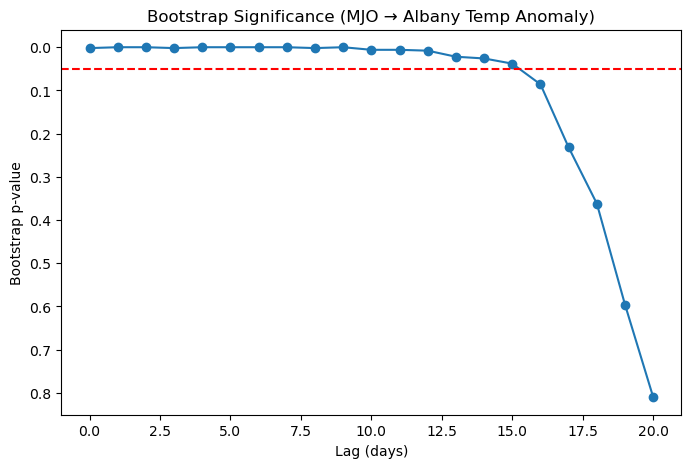

In [16]:
plt.figure(figsize=(8,5))
plt.plot(boot_df["lag"], boot_df["p_bootstrap"], "-o")
plt.axhline(0.05, color="red", linestyle="--")
plt.xlabel("Lag (days)")
plt.ylabel("Bootstrap p-value")
plt.title("Bootstrap Significance (MJO → Albany Temp Anomaly)")
plt.gca().invert_yaxis()
plt.show()

In [17]:
merged["month"] = merged["valid_time"].dt.month
strong = merged[(merged["amplitude"] > 1) & (merged["month"].isin([11,12,1,2,3]))]

In [18]:
lags = range(0, 21)
results = []

for lag in lags:
    df_lag = strong.copy()
    df_lag["temp_lag"] = df_lag["temp_anom"].shift(-lag)  # future temp
    df_lag = df_lag.dropna(subset=["temp_lag", "RMM1", "RMM2"])

    X = df_lag[["RMM1", "RMM2"]]
    X = sm.add_constant(X)
    y = df_lag["temp_lag"]

    model = sm.OLS(y, X).fit()
    results.append(model.params)

In [19]:
lag_df = pd.DataFrame(results)
lag_df["lag_days"] = lags

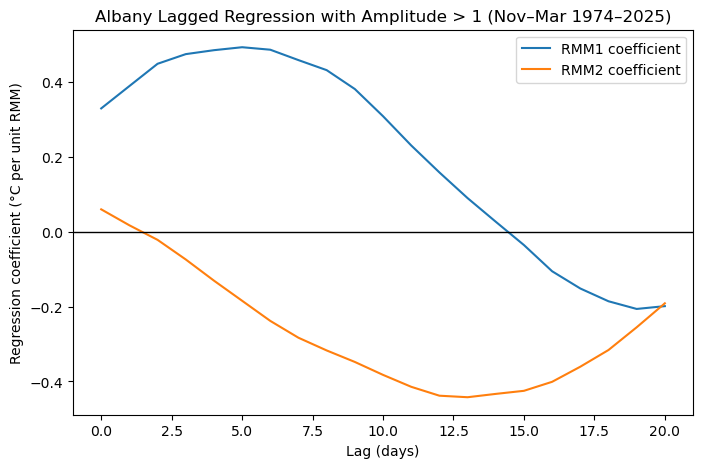

In [20]:
plt.figure(figsize=(8,5))
plt.plot(lag_df["lag_days"], lag_df["RMM1"], label="RMM1 coefficient")
plt.plot(lag_df["lag_days"], lag_df["RMM2"], label="RMM2 coefficient")
plt.axhline(0, color="k", linewidth=1)

plt.xlabel("Lag (days)")
plt.ylabel("Regression coefficient (°C per unit RMM)")
plt.title("Albany Lagged Regression with Amplitude > 1 (Nov–Mar 1974–2025)")
plt.legend()
plt.show()

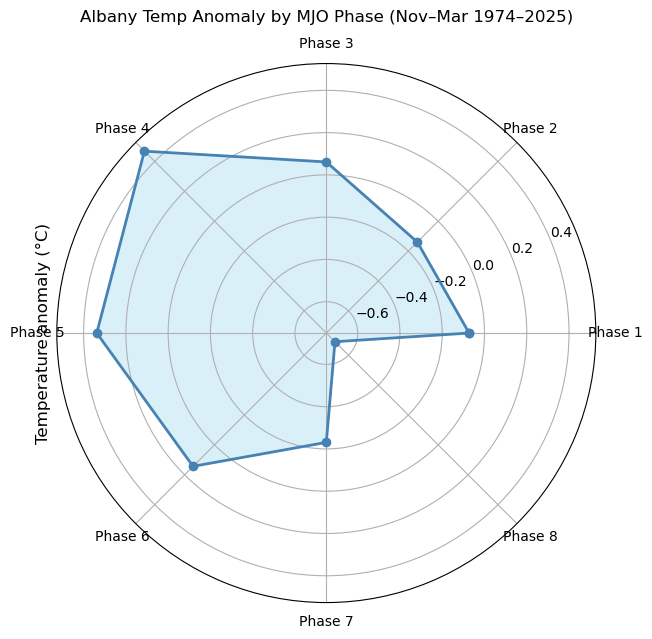

In [21]:
# Mean anomaly by phase (already computed)
values = phase_mean.values

# Close the loop (phase 8 connects back to phase 1)
values = np.append(values, values[0])

# Define phase angles (1–8 → equally spaced around circle)
phases = np.arange(1, 9)
angles = np.deg2rad(np.linspace(0, 360, 9))  # 9 points incl. closure

plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

# Plot line
ax.plot(angles, values, marker='o', linewidth=2, color="steelblue")

# Fill
ax.fill(angles, values, alpha=0.3, color="skyblue")

# Set phase labels around the circle
ax.set_xticks(np.deg2rad(np.linspace(0, 360, 8, endpoint=False)))
ax.set_xticklabels([f"Phase {p}" for p in phases])

# Radial label
ax.set_ylabel("Temperature anomaly (°C)", fontsize=12)

ax.set_title("Albany Temp Anomaly by MJO Phase (Nov–Mar 1974–2025)", pad=30)

plt.show()

In [22]:
# keep Nov–Mar only
df = merged.copy()
df["date"]  = pd.to_datetime(df["valid_time"])
df["month"] = df["date"].dt.month
df = df[df["month"].isin([11,12,1,2,3])].sort_values("date").reset_index(drop=True)

# MJO phase angle + sin/cos
# (phase index here is the standard 1..8, rotating CCW)
df["phase_angle"] = np.arctan2(df["RMM2"], df["RMM1"])  # radians
phase_deg = np.degrees(df["phase_angle"]) % 360.0
df["phase_idx"] = ((phase_deg // 45) + 1).astype(int)   # 1..8

df["phase_sin"] = np.sin(df["phase_angle"])
df["phase_cos"] = np.cos(df["phase_angle"])

# useful regime flags
df["active"] = (df["amplitude"] > 1.0).astype(int)

In [23]:
LAGS = [1, 3, 5, 7, 10, 14]  # compact, physically motivated

def make_features(frame, lags=LAGS):
    X = frame.copy()
    # lagged RMMs (predictors measured at time t for target at t+τ)
    for L in lags:
        X[f"RMM1_lag{L}"] = X["RMM1"].shift(L)
        X[f"RMM2_lag{L}"] = X["RMM2"].shift(L)
    # local persistence / state
    X["AR1"]   = X["temp_anom"].shift(1)
    X["MA7"]   = X["temp_anom"].rolling(7, min_periods=1).mean()
    # keep phase & regime features
    keep = [c for c in X.columns if c.startswith("RMM") or c in
            ["AR1","MA7","phase_sin","phase_cos","amplitude","active","date","temp_anom","phase_idx"]]
    return X[keep]

Xfull = make_features(df)

In [24]:
def build_composite(train_df, leads, amp_thresh=1.0):
    """
    Returns:
      comp: {lead: {(phase_idx, active): mean_temp_anom}}
      fallback: {lead: overall_mean}
    """
    comp = {}
    fallback = {}
    for τ in leads:
        tmp = train_df.copy()
        tmp[f"y_lead{τ}"] = tmp["temp_anom"].shift(-τ)
        tmp = tmp.dropna(subset=[f"y_lead{τ}"])
        tmp["active"] = (tmp["amplitude"] > amp_thresh).astype(int)
        grp = tmp.groupby(["phase_idx","active"])[f"y_lead{τ}"].mean()
        comp[τ] = grp.to_dict()
        fallback[τ] = tmp[f"y_lead{τ}"].mean()
    return comp, fallback

In [25]:
# simple first pass: 1974–2010 train, 2011–2025 test
split_date = pd.Timestamp("2011-01-01")

train_mask = Xfull["date"] < split_date
test_mask  = Xfull["date"] >= split_date

train = Xfull.loc[train_mask].reset_index(drop=True)
test  = Xfull.loc[test_mask].reset_index(drop=True)

LEADS = range(1, 15)  # 1–14 days

In [26]:
def fit_ridge_per_lead(train, test, lead):
    """
    Fit RidgeCV for y(t+lead) using features at t.
    Returns predictions for the *test* rows that have a target defined.
    """
    tr = train.copy()
    te = test.copy()

    # build targets
    tr["y"] = tr["temp_anom"].shift(-lead)
    te["y"] = te["temp_anom"].shift(-lead)

    # feature columns (exclude targets, dates, identifiers)
    drop_cols = ["temp_anom", "date", "y", "phase_idx"]
    feat_cols = [c for c in tr.columns if c not in drop_cols]

    # align rows with available target
    tr_fit = tr.dropna(subset=["y"] + feat_cols).copy()
    te_fit = te.dropna(subset=["y"] + feat_cols).copy()

    X_tr, y_tr = tr_fit[feat_cols].values, tr_fit["y"].values
    X_te, y_te = te_fit[feat_cols].values, te_fit["y"].values

    # pipeline: standardize → Ridge (alpha via CV)
    ridge = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("model",  RidgeCV(alphas=np.logspace(-3, 3, 25)))
    ])
    ridge.fit(X_tr, y_tr)
    yhat_te = ridge.predict(X_te)

    # residual std on train (for PIs)
    yhat_tr = ridge.predict(X_tr)
    resid   = y_tr - yhat_tr
    sigma   = resid.std(ddof=1)

    return te_fit[["date","phase_idx","active","amplitude"]].assign(
        ridge_mean=yhat_te, ridge_sigma=sigma, y_true=y_te
    )

# build composite table on TRAIN only
comp_tbl, comp_fallback = build_composite(
    pd.concat([train[["date","temp_anom","phase_idx","amplitude"]]], axis=1),
    leads=LEADS, amp_thresh=1.0
)

# helper to fetch composite prediction for a row
def comp_predict_row(phase_idx, active, lead):
    d = comp_tbl[lead]
    return d.get((int(phase_idx), int(active)), comp_fallback[lead])

# run all leads & merge results
out_list = []
for τ in LEADS:
    res = fit_ridge_per_lead(train, test, τ)
    # composite prediction for same rows
    comp_vals = [comp_predict_row(p, a, τ) for p, a in zip(res["phase_idx"], res["active"])]
    res = res.assign(comp_mean = comp_vals)
    # simple mean ensemble
    res = res.assign(ens_mean = 0.5*res["ridge_mean"] + 0.5*res["comp_mean"],
                     lead = τ)
    out_list.append(res)

results = pd.concat(out_list, ignore_index=True)

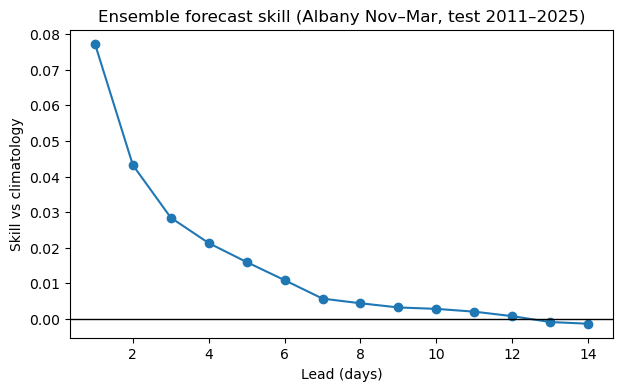

In [27]:
def rmse(a, b): return np.sqrt(np.mean((np.asarray(a)-np.asarray(b))**2))

scores = []
for τ in LEADS:
    sub = results[results["lead"] == τ].dropna(subset=["y_true","ens_mean"])
    if len(sub) == 0: 
        scores.append({"lead": τ, "rmse": np.nan, "skill": np.nan})
        continue
    # model RMSE
    rmse_model = rmse(sub["ens_mean"], sub["y_true"])
    # climatology RMSE: zero-anomaly baseline (winter mean ~ 0 by construction)
    rmse_climo = rmse(np.zeros_like(sub["y_true"]), sub["y_true"])
    skill = 1.0 - (rmse_model / rmse_climo)
    scores.append({"lead": τ, "rmse": rmse_model, "skill": skill})

score_df = pd.DataFrame(scores)

plt.figure(figsize=(7,4))
plt.plot(score_df["lead"], score_df["skill"], marker="o")
plt.axhline(0, color="k", lw=1)
plt.xlabel("Lead (days)")
plt.ylabel("Skill vs climatology")
plt.title("Ensemble forecast skill (Albany Nov–Mar, test 2011–2025)")
plt.show()

In [28]:
coef_list = []

for τ in LEADS:
    tr = train.copy()
    tr["y"] = tr["temp_anom"].shift(-τ)
    drop_cols = ["temp_anom", "date", "y", "phase_idx"]
    feat_cols = [c for c in tr.columns if c not in drop_cols]
    tr_fit = tr.dropna(subset=["y"] + feat_cols)
    X_tr, y_tr = tr_fit[feat_cols].values, tr_fit["y"].values

    ridge = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("model", RidgeCV(alphas=np.logspace(-3, 3, 25)))
    ])
    ridge.fit(X_tr, y_tr)

    coefs = ridge.named_steps["model"].coef_
    coef_dict = {"lead": τ}
    for f, b in zip(feat_cols, coefs):
        coef_dict[f] = b
    coef_list.append(coef_dict)

coef_df = pd.DataFrame(coef_list)

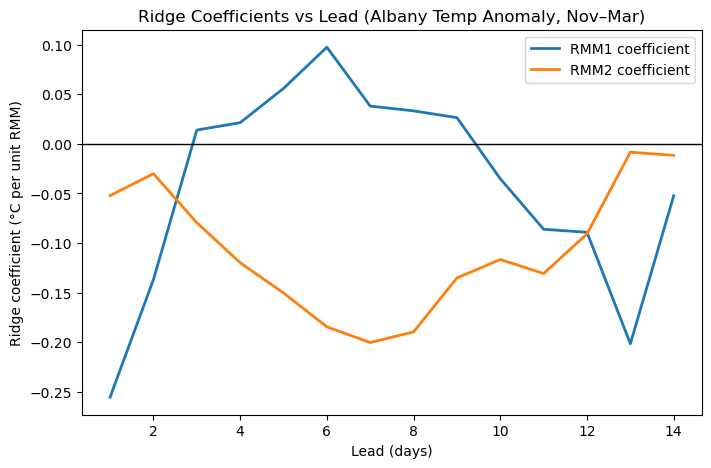

In [29]:
plt.figure(figsize=(8,5))
plt.plot(coef_df["lead"], coef_df["RMM1"], label="RMM1 coefficient", lw=2)
plt.plot(coef_df["lead"], coef_df["RMM2"], label="RMM2 coefficient", lw=2)
plt.axhline(0, color="k", lw=1)
plt.xlabel("Lead (days)")
plt.ylabel("Ridge coefficient (°C per unit RMM)")
plt.title("Ridge Coefficients vs Lead (Albany Temp Anomaly, Nov–Mar)")
plt.legend()
plt.show()

# The MJO’s eastward convective envelope has a real but transient teleconnection: positive RMM1 → warmer Northeast US about a week later; positive RMM2 → cooler anomalies. This reflects the canonical MJO → PNA → Eastern US response pattern.

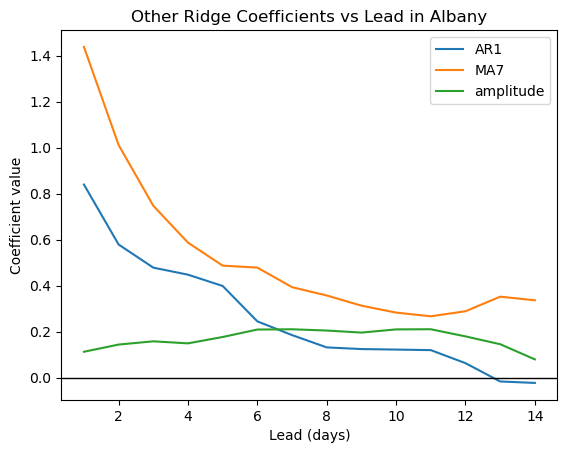

In [30]:
for f in ["AR1", "MA7", "amplitude"]:
    if f in coef_df.columns:
        plt.plot(coef_df["lead"], coef_df[f], label=f)

plt.axhline(0, color="k", lw=1)
plt.xlabel("Lead (days)")
plt.ylabel("Coefficient value")
plt.title("Other Ridge Coefficients vs Lead in Albany")
plt.legend()
plt.show()

# An autoregressive lag-1 (AR1) term quantifies the persistence of daily temperature anomalies, or how strongly today’s anomaly depends on yesterday’s. Its influence decays rapidly with lead time, as the atmosphere’s memory of local temperature patterns fades beyond a few days. 

# A 7-day moving-average (MA7) term represents the smoothed persistence of recent temperature anomalies — essentially the slowly varying background state. Its predictive influence decays quickly, showing that beyond about a week, the local anomaly memory adds little skill.

# The MJO amplitude term (green line) peaks around 10–12 days, roughly twice the timescale of the RMM1/RMM2 phase response. This reflects the persistence of the MJO envelope itself. Even after the specific phase-locked pattern weakens around day 7, a high-amplitude MJO (> 1) continues to enhance global predictability. While the direction of the MJO forcing matters most early on, its strength sustains teleconnection skill out to two weeks.

In [31]:
print(sorted(res["lead"].unique()))

[np.int64(14)]


In [32]:
def fit_ridge_per_lead(train, test, lead):
    df = train.copy()

    # --- Shift targets and amplitude forward by lead days ---
    df["temp_anom_lead"] = df["temp_anom"].shift(-lead)
    df["amplitude_lead"] = df["amplitude"].shift(-lead)

    # --- Drop rows with missing data (from shifting or NaNs anywhere) ---
    df = df.dropna(subset=[
        "temp_anom_lead", "RMM1", "RMM2", "amplitude_lead",
        "phase_idx", "active", "AR1", "MA7"
    ])

    # --- Prepare predictors and target ---
    X_tr = df[["RMM1", "RMM2", "amplitude_lead", "phase_idx", "active", "AR1", "MA7"]]
    y_tr = df["temp_anom_lead"]

    # --- Drop any remaining NaNs just in case ---
    mask = X_tr.notna().all(axis=1)
    X_tr = X_tr[mask]
    y_tr = y_tr[mask]

    # --- Ridge regression with scaling ---
    ridge = RidgeCV(alphas=np.logspace(-3, 3, 25))
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_tr)

    ridge.fit(X_scaled, y_tr)

    # --- Extract amplitude coefficient ---
    coef_amp = ridge.coef_[X_tr.columns.get_loc("amplitude_lead")]

    return pd.DataFrame({
        "lead": [lead],
        "coef_amplitude": [coef_amp],
        "amplitude_mean": [df["amplitude_lead"].mean()]
    })

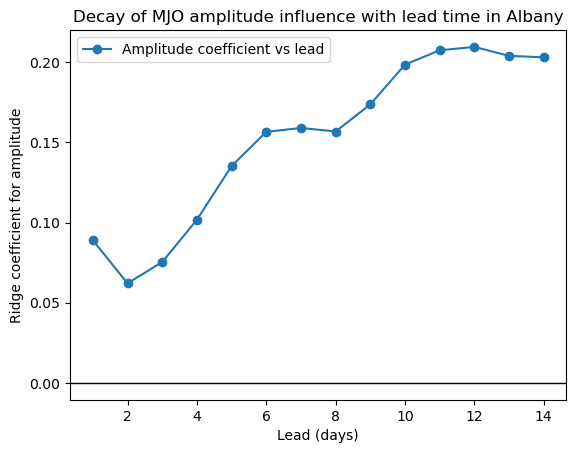

In [33]:
res = pd.concat(
    [fit_ridge_per_lead(train, test, τ) for τ in range(1, 15)],
    ignore_index=True
)

plt.plot(res["lead"], res["coef_amplitude"], "o-", label="Amplitude coefficient vs lead")
plt.xlabel("Lead (days)")
plt.ylabel("Ridge coefficient for amplitude")
plt.title("Decay of MJO amplitude influence with lead time in Albany")
plt.axhline(0, color="k", lw=1)
plt.legend()
plt.show()

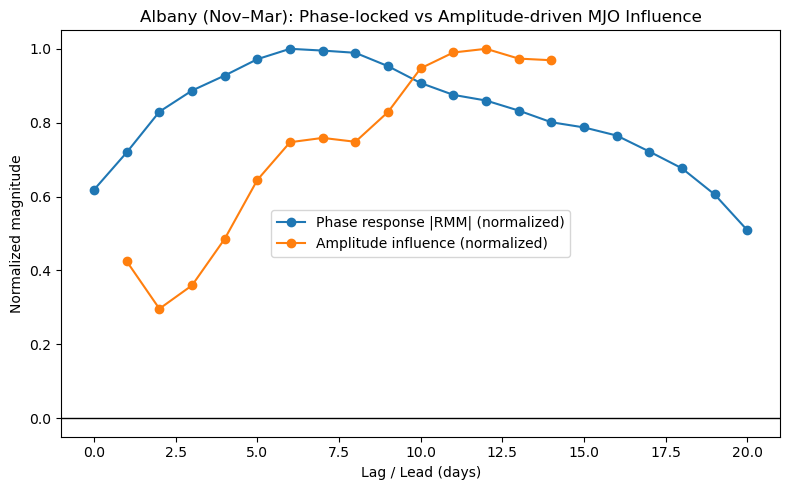

In [34]:
# --- Recompute |RMM| magnitude (phase-locked signal strength) ---
lag_df["phase_mag"] = np.sqrt(lag_df["RMM1"]**2 + lag_df["RMM2"]**2)

# --- Normalize both curves ---
phase_norm = lag_df["phase_mag"] / lag_df["phase_mag"].max()
amp_norm = res["coef_amplitude"] / res["coef_amplitude"].max()

# --- Plot ---
plt.figure(figsize=(8,5))
plt.plot(lag_df["lag_days"], phase_norm, "o-", label="Phase response |RMM| (normalized)")
plt.plot(res["lead"], amp_norm, "o-", label="Amplitude influence (normalized)")
plt.axhline(0, color="k", lw=1)
plt.xlabel("Lag / Lead (days)")
plt.ylabel("Normalized magnitude")
plt.title("Albany (Nov–Mar): Phase-locked vs Amplitude-driven MJO Influence")
plt.legend()
plt.tight_layout()
plt.show()

# MJO amplitude is a predictability amplifier for midlatitude anomalies, strongest at ~1–2 weeks lead, when the tropical-extratropical coupling peaks.

# When the MJO’s amplitude is strong, its planetary wave train remains coherent for longer — so the extratropical atmosphere retains a memory of the tropical forcing for up to two weeks.

# The phase-locked response is the instantaneous impact — where a specific phase (e.g., Indian Ocean vs Maritime Continent convection) projects onto local anomaly signs.

# The amplitude-driven signal is the statistical predictability effect — strong MJO means stronger and more stable teleconnections overall.

# Phase delivers the signal; amplitude controls the strength and longevity of that signal.

# Blue curve is derived from the |RMM| composite and represents how strongly temperature anomalies in Albany co-vary with the orientation of the MJO pattern (RMM1/RMM2 phase).

# Orange curve shows how much more predictable the local anomaly pattern is, regardless of phase, when the MJO is strong overall.

In [35]:
# ----------------------------------------------------------
# 0. Start from merged dataset
# ----------------------------------------------------------

df = merged.copy()

# --- Convert temperature to anomaly (w.r.t full climatology) ---
df["temp_anom"] = df["temp_C"] - df["temp_C"].mean()

# --- Create phase index (1–8) ---
phase_map = {1:1, 2:2, 3:3, 4:4, 5:5, 6:6, 7:7, 8:8}
df["phase_idx"] = df["phase"].map(phase_map).astype(int)

# --- Active MJO flag ---
df["active"] = (df["amplitude"] > 1).astype(int)

# --- Persistence predictors ---
df["AR1"] = df["temp_anom"].shift(1)
df["MA7"] = df["temp_anom"].rolling(7).mean()

# --- Drop initial NA rows (from AR1 / MA7) ---
df = df.dropna().reset_index(drop=True)

print(df.head())
print(df.columns)

  valid_time    temp_C     date_x  month  doy  temp_anom     date_y      RMM1  \
0 1974-11-21  6.278413 1974-11-21     11  325   6.519642 1974-11-21 -0.173980   
1 1974-11-22 -2.403424 1974-11-22     11  326  -2.162195 1974-11-22  0.312823   
2 1974-11-23 -3.030393 1974-11-23     11  327  -2.789165 1974-11-23  0.862785   
3 1974-11-24  2.017897 1974-11-24     11  328   2.259126 1974-11-24  0.853498   
4 1974-11-25  4.752438 1974-11-25     11  329   4.993666 1974-11-25  0.970875   

       RMM2  phase  amplitude       date  RMM1_lag  RMM2_lag  phase_idx  \
0  0.754785      7   0.774577 1974-11-21  0.527685  0.175881          7   
1  0.643428      6   0.715443 1974-11-22  0.327812  0.435784          6   
2  0.618138      5   1.061360 1974-11-23  0.298643  0.705654          5   
3  0.405564      5   0.944955 1974-11-24  0.457460  0.550047          5   
4  0.384895      5   1.044390 1974-11-25  0.459280  0.492161          5   

   active       AR1       MA7  
0       0  6.790017  4.885236 

In [36]:
# --------------------------------------------------------------
# 0. Predictor set for OPTION A (no RMM lags)
# --------------------------------------------------------------
PRED_COLS = ["RMM1", "RMM2", "amplitude", "phase_idx", "active", "AR1", "MA7"]

# df is your merged dataframe with:
# ['valid_time','temp_C','date_x','month','doy','temp_anom',
#  'date_y','RMM1','RMM2','phase','amplitude','date',
#  'RMM1_lag','RMM2_lag','phase_idx','active','AR1','MA7']
# and NA rows from AR1/MA7 already dropped.

# Make sure it's sorted by date
df = df.sort_values("date").reset_index(drop=True)

# --------------------------------------------------------------
# 1. Expand to a lead-time table (target at t+L, predictors at t)
# --------------------------------------------------------------
def expand_leads(df, max_lead=14):
    rows = []
    n = len(df)

    for i in range(n):
        for L in range(1, max_lead + 1):
            if i + L >= n:
                continue  # not enough data to verify this lead

            rows.append({
                "init_index": i,
                "init_date": df["date"].iloc[i],
                "verify_date": df["date"].iloc[i + L],
                "lead": L,

                # target at t+L
                "temp_anom_lead": df["temp_anom"].iloc[i + L],

                # predictors at time t (OPTION A)
                "RMM1": df["RMM1"].iloc[i],
                "RMM2": df["RMM2"].iloc[i],
                "amplitude": df["amplitude"].iloc[i],
                "phase_idx": df["phase_idx"].iloc[i],
                "active": df["active"].iloc[i],
                "AR1": df["AR1"].iloc[i],
                "MA7": df["MA7"].iloc[i],
            })

    return pd.DataFrame(rows)

max_lead = 14
df_leads = expand_leads(df, max_lead=max_lead)

print("Expanded lead table shape:", df_leads.shape)
print(df_leads.head())

# --------------------------------------------------------------
# 2. Helper: fit ridge for a single lead using OPTION A predictors
# --------------------------------------------------------------
def fit_ridge_single(train_df, test_df):
    """
    Train RidgeCV on train_df and predict for test_df.
    Returns a DataFrame with columns ['yhat', 'sigma'] for test_df rows.
    """
    X_tr = train_df[PRED_COLS].values
    y_tr = train_df["temp_anom_lead"].values

    X_te = test_df[PRED_COLS].values

    ridge = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("model", RidgeCV(alphas=np.logspace(-3, 3, 25)))
    ])

    ridge.fit(X_tr, y_tr)

    # Predictions
    yhat_te = ridge.predict(X_te)

    # Residual std on training set (for rough uncertainty)
    yhat_tr = ridge.predict(X_tr)
    sigma = np.std(y_tr - yhat_tr, ddof=1)

    out = pd.DataFrame({
        "yhat": yhat_te,
        "ridge_sigma": sigma
    }, index=test_df.index)

    return out

# --------------------------------------------------------------
# 3. Rolling-origin cross-validation across time
# --------------------------------------------------------------
def rolling_cv(df_leads, min_train_days=365 * 10, max_lead=14):
    """
    Rolling-origin CV:
      - For each initial date i after a burn-in period,
        train on all earlier initial dates and test on date i.
    """
    results = []
    init_indices = sorted(df_leads["init_index"].unique())

    for init in init_indices:
        # Require some history before we start validating
        if init < min_train_days:
            continue

        train_mask = df_leads["init_index"] < init
        test_mask = df_leads["init_index"] == init

        for L in range(1, max_lead + 1):
            tr = df_leads[train_mask & (df_leads["lead"] == L)]
            te = df_leads[test_mask & (df_leads["lead"] == L)]

            if len(tr) < 50 or len(te) == 0:
                continue

            fit_out = fit_ridge_single(tr, te)

            for idx in te.index:
                row = te.loc[idx]
                results.append({
                    "init_date": row["init_date"],
                    "verify_date": row["verify_date"],
                    "lead": int(row["lead"]),
                    "y_true": row["temp_anom_lead"],
                    "ridge_mean": fit_out.loc[idx, "yhat"],
                    "ridge_sigma": fit_out.loc[idx, "ridge_sigma"],
                    "phase_idx": int(row["phase_idx"]),
                    "active": int(row["active"]),
                    "amplitude": row["amplitude"],
                })

    return pd.DataFrame(results)

cv_res = rolling_cv(df_leads, max_lead=max_lead)
print("CV rows:", len(cv_res))
print(cv_res.head())

# --------------------------------------------------------------
# 4. Add composite and ensemble mean
# --------------------------------------------------------------
def add_composite_and_ensemble(df):
    comp_vals = []

    for _, r in df.iterrows():
        phase = int(r["phase_idx"])
        active = int(r["active"])
        lead  = int(r["lead"])

        # Use your existing composite predictor (3 args only!)
        comp_val = comp_predict_row(phase, active, lead)

        comp_vals.append(comp_val)

    df["comp_mean"] = comp_vals

    # Blend ridge + composite
    df["ens_mean"] = 0.5 * df["ridge_mean"] + 0.5 * df["comp_mean"]

    return df
    
cv_res = add_composite_and_ensemble(cv_res)
print(cv_res.head())

# --------------------------------------------------------------
# 5. Compute RMSE & skill vs climatology for each lead
# --------------------------------------------------------------
def compute_skill(cv_res):
    def _skill_one_group(d):
        rmse_model = np.sqrt(np.mean((d["ens_mean"] - d["y_true"])**2))
        rmse_climo = np.sqrt(np.mean((0.0 - d["y_true"])**2))   # climatology = 0 anomaly
        return pd.Series({
            "rmse_model": rmse_model,
            "rmse_climo": rmse_climo
        })

    skill_tbl = cv_res.groupby("lead").apply(_skill_one_group)
    skill_tbl["skill"] = 1 - (skill_tbl["rmse_model"]**2 / skill_tbl["rmse_climo"]**2)
    skill_tbl = skill_tbl.reset_index()

    return skill_tbl

skill_tbl = compute_skill(cv_res)
print(skill_tbl)

# --------------------------------------------------------------
# 6. Optional: per-lead bias for later bias correction in real-time
# --------------------------------------------------------------
bias_tbl = (
    cv_res.groupby("lead")
    .apply(lambda d: np.mean(d["ens_mean"] - d["y_true"]))
    .rename("bias")
    .reset_index()
)

print(bias_tbl)

Expanded lead table shape: (103929, 12)
   init_index  init_date verify_date  lead  temp_anom_lead     RMM1      RMM2  \
0           0 1974-11-21  1974-11-22     1       -2.162195 -0.17398  0.754785   
1           0 1974-11-21  1974-11-23     2       -2.789165 -0.17398  0.754785   
2           0 1974-11-21  1974-11-24     3        2.259126 -0.17398  0.754785   
3           0 1974-11-21  1974-11-25     4        4.993666 -0.17398  0.754785   
4           0 1974-11-21  1974-11-26     5       -3.141973 -0.17398  0.754785   

   amplitude  phase_idx  active       AR1       MA7  
0   0.774577          7       0  6.790017  4.885236  
1   0.774577          7       0  6.790017  4.885236  
2   0.774577          7       0  6.790017  4.885236  
3   0.774577          7       0  6.790017  4.885236  
4   0.774577          7       0  6.790017  4.885236  
CV rows: 52829
   init_date verify_date  lead    y_true  ridge_mean  ridge_sigma  phase_idx  \
0 1999-02-25  1999-02-26     1 -0.275048   -4.138755  

/var/folders/y2/bm_n0z_s0hn02828pw4hyhgh0000gn/T/ipykernel_13122/3177954659.py:175: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  skill_tbl = cv_res.groupby("lead").apply(_skill_one_group)
/var/folders/y2/bm_n0z_s0hn02828pw4hyhgh0000gn/T/ipykernel_13122/3177954659.py:189: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: np.mean(d["ens_mean"] - d["y_true"]))


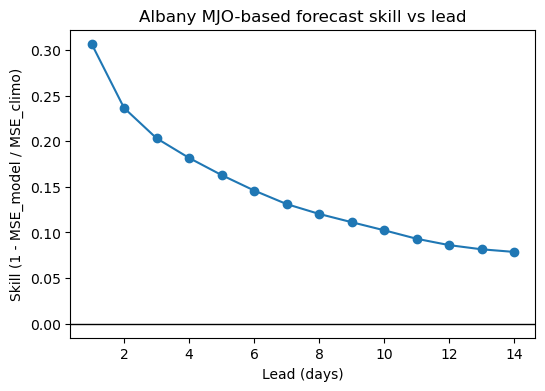

In [37]:
plt.figure(figsize=(6,4))
plt.plot(skill_tbl["lead"], skill_tbl["skill"], "-o")
plt.axhline(0, color="k", lw=1)
plt.xlabel("Lead (days)")
plt.ylabel("Skill (1 - MSE_model / MSE_climo)")
plt.title("Albany MJO-based forecast skill vs lead")
plt.show()

In [38]:
df = df.copy()  # merged/engineered dataset

# --- Phase angle (0–360°) ---
df["theta"] = np.degrees(np.arctan2(df["RMM2"], df["RMM1"]))
df["theta"] = (df["theta"] + 360) % 360

# --- Phase-speed (degrees/day) ---
theta_diff = (df["theta"].diff() + 540) % 360 - 180
df["phase_speed"] = theta_diff.abs()   # magnitude, no direction

In [39]:
bins = [0, 5, 10, 360]
labels = ["slow", "normal", "fast"]

df["speed_cat"] = pd.cut(df["phase_speed"], bins=bins, labels=labels, right=False)

In [40]:
print(df["speed_cat"].value_counts())

speed_cat
fast      3461
slow      2037
normal    1932
Name: count, dtype: int64


In [41]:
comp_speed = (
    df.groupby("speed_cat")["temp_anom"]
      .mean()
      .rename("mean_anom")
      .to_frame()
)

print(comp_speed)

           mean_anom
speed_cat           
slow       -0.502532
normal      0.227284
fast        0.125002


/var/folders/y2/bm_n0z_s0hn02828pw4hyhgh0000gn/T/ipykernel_13122/579310820.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("speed_cat")["temp_anom"]


In [42]:
comp_phase_speed = (
    df.groupby(["phase_idx", "speed_cat"])["temp_anom"]
      .mean()
      .unstack()
)

print(comp_phase_speed)

speed_cat      slow    normal      fast
phase_idx                              
1          0.307272  1.386098  0.325856
2         -0.313089  0.267582  0.632781
3         -0.051404  0.656810  0.234689
4          1.301875  0.672146  0.431445
5         -0.021787  1.065252  0.039910
6         -1.137763 -0.598282  0.233282
7         -2.048815 -0.546833 -0.619040
8         -1.370554 -0.502803 -0.154290


/var/folders/y2/bm_n0z_s0hn02828pw4hyhgh0000gn/T/ipykernel_13122/565263452.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["phase_idx", "speed_cat"])["temp_anom"]


In [47]:
df_leads = df_leads.merge(
    df[["date", "speed_cat"]],
    left_on="init_date",
    right_on="date",
    how="left"
)

df_leads = df_leads.drop(columns=["date"])   # optional cleanup

def fit_speed_subset(df_sub, lead):
    # Only keep rows for chosen lead
    df_sub = df_sub[df_sub["lead"] == lead].dropna(subset=["temp_anom_lead"])

    X = df_sub[["RMM1", "RMM2", "amplitude", "AR1", "MA7"]].values
    y = df_sub["temp_anom_lead"].values

    model = Pipeline([
        ("scale", StandardScaler()),
        ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 25)))
    ])

    model.fit(X, y)
    return model.named_steps["ridge"].coef_
lead = 7

beta_slow = fit_speed_subset(df_leads[df_leads["speed_cat"]=="slow"], lead)
beta_fast = fit_speed_subset(df_leads[df_leads["speed_cat"]=="fast"], lead)

print("Slow MJO coefficients:", beta_slow)
print("Fast MJO coefficients:", beta_fast)

Slow MJO coefficients: [ 0.05913761 -0.75076838  0.26514717  0.56858572  1.93910051]
Fast MJO coefficients: [-0.05023398 -0.37545096  0.09075238  0.37687366  2.42532831]
